# Shortlist countries: Indonesia · Philippines · Vietnam

Detailed per-country analysis behind `docs/SHORTLIST_REVIEW_IDN_PHL_VNM.md`
(2026-08-18 visual review of the `world_v10_fourclass_v9` map).

**Finding any example on our map:** every example below carries two links —

- **map** → `animalfarmingatlas.org/map?ds=world_v10_fourclass_v9&sel=<id>`
  opens our web map with that candidate selected and its detail panel open
  (after the next web deploy the map also flies straight to it);
- **sat** → the same coordinates in Google Maps satellite view, for
  independent high-res imagery.

Verdicts come from by-eye inspection of Esri World Imagery (640 px @ zoom 17
≈ 0.6 km field, matching the model's 64 px input crop). Sampling manifest:
`experiments/results/shortlist_review_manifest.csv` (seed 42).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import HTML, display

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "experiments"))
import lib

# validated palette (dataviz reference instance)
POULTRY, PIGS, CATTLE = "#eb6834", "#1baf7a", "#2a78d6"   # slots 2,3,1
NOTFARM = "#8a8984"                                        # neutral, not a series
GOOD, BAD, WARN = "#0ca30c", "#d03b3b", "#a15c00"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#8a8984"
CLASS_COLOR = {"NotFarm": NOTFARM, "Poultry": POULTRY, "Pigs": PIGS, "Cattle": CATTLE}
CLASSES = ["NotFarm", "Poultry", "Pigs", "Cattle"]

mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "figure.dpi": 110,
})

df = lib.load(lib.FOURCLASS["v9"])
df = df[df.ADM0.isin(["IDN", "PHL", "VNM"])].copy()
df["p_farm"] = 1.0 - df.prob_class0
df["pred"] = df.predicted_label.map(dict(enumerate(CLASSES)))
manifest = pd.read_csv(lib.RESULTS / "shortlist_review_manifest.csv")

MAP = "https://animalfarmingatlas.org/map?ds=world_v10_fourclass_v9&sel={cid}"
SAT = "https://www.google.com/maps/@{lat:.6f},{lng:.6f},800m/data=!3m1!1e3"

def links(cid):
    r = df[df.candidate_id == cid].iloc[0]
    return (f'<a href="{MAP.format(cid=cid)}">map</a> · '
            f'<a href="{SAT.format(lat=r.lat, lng=r.lng)}">sat</a>')

def link_table(rows):
    "rows: list of dicts with candidate_id [+ extra cols]; renders with map/sat links"
    t = pd.DataFrame(rows)
    t["find it"] = t.candidate_id.map(links)
    return HTML(t.to_html(escape=False, index=False))

print(f"{len(df):,} candidates across {df.ADM0.nunique()} countries")

6,696 candidates across 3 countries


## Inspection verdicts

The ground truth of this notebook: every individually inspected site, with the
model's call, the label (if any), and what the imagery actually shows.
`verdict` is farm-level (was the farm/not-farm call right); `type_ok` judges
the species call where a farm is present and the imagery decides it.

In [2]:
V = pd.DataFrame([
 # iso, candidate_id, stratum, model_pred, p_farm, label, verdict, type_ok, note
 ("VNM","VNM_cluster_33","poultry_top","Poultry",1.00,None,"right",True,"Eight-barn complex on cleared ground in Red River paddies"),
 ("VNM","VNM_cluster_4021","poultry_top","Poultry",1.00,None,"right",True,"Two barn groups (5+3) carved into orchard land"),
 ("VNM","VNM_cluster_4311","poultry_top","Poultry",1.00,None,"right",True,"Two fenced integrator compounds, CP-style"),
 ("VNM","VNM_cluster_499","poultry_top","Poultry",1.00,None,"right",True,"Twin dense blocks of ~8+6 barns with red support buildings"),
 ("VNM","VNM_cluster_5948","poultry_top","Poultry",1.00,None,"right",None,"15+ barns; dark pond suggests pigs possible"),
 ("VNM","VNM_cluster_6827","poultry_top","Poultry",1.00,None,"right",None,"Three joined wide barns in young plantation"),
 ("VNM","VNM_cluster_4332","pigs_top","Pigs",1.00,None,"right",True,"Dozens of barns + two REDDISH anaerobic lagoons - textbook swine"),
 ("VNM","VNM_cluster_5843","pigs_top","Pigs",1.00,None,"right",True,"Barn block ringed by dark treatment/fish ponds (VAC pattern)"),
 ("VNM","VNM_cluster_6825","pigs_top","Pigs",0.99,None,"right",True,"Ten barns, three dark lagoons alongside"),
 ("VNM","VNM_cluster_291","notfarm_top","NotFarm",0.01,None,"right",None,"Coastal theme park + rowhouse development"),
 ("VNM","VNM_cluster_2409","notfarm_top","NotFarm",0.01,None,"right",None,"Beach resort; villa rows fooled the footprint filter"),
 ("VNM","VNM_cluster_4450","borderline","Poultry",0.5,None,"ambiguous",None,"Smallholder sheds vs crop tarps - uncertainty appropriate"),
 ("VNM","VNM_cluster_2386","disagreement","Poultry",1.00,"NotFarm","label right",None,"Shade-net/greenhouse rows in Mekong village strip"),
 ("VNM","VNM_cluster_8176","disagreement","Poultry",0.96,"NotFarm","contested",None,"Dark-roof rows on hillside; genuinely livestock-like - re-annotate"),
 ("VNM","VNM_cluster_1035","disagreement","Poultry",0.94,"NotFarm","label right",None,"Net-house/nursery rows beside aquaculture ponds"),
 ("IDN","IDN_cluster_2662","poultry_top","Poultry",1.00,None,"right",True,"Open kandang (dark roofs) + closed-house (white) side by side"),
 ("IDN","IDN_cluster_10062","poultry_top","Poultry",1.00,None,"right",None,"Shed strip along farm road in paddies"),
 ("IDN","IDN_cluster_2189","pigs_top","Pigs",0.98,None,"no structure",False,"Batam: nothing visible at location - mislocation or stale imagery"),
 ("IDN","IDN_cluster_5125","disagreement","Pigs",0.83,"Cattle","right",False,"Lampung feedlot: farm yes, but Cattle -> Pigs (unlearnable class)"),
 ("IDN","IDN_cluster_7103","disagreement","Poultry",0.57,"NotFarm","label right",None,"School/barracks compound, East Java; model hedged at 0.57"),
 ("IDN","IDN_cluster_1988","notfarm_top","NotFarm",0.00,None,"right",None,"Lake aquaculture cage rafts, correctly refused"),
 ("IDN","IDN_cluster_494","borderline","NotFarm",0.5,None,"ambiguous",None,"Pesantren/school + greenhouse rows; probably NotFarm"),
 ("PHL","PHL_cluster_1053","poultry_top","Poultry",1.00,None,"right",True,"Rusty open-sided houses among smallholdings + fish ponds"),
 ("PHL","PHL_cluster_285","pigs_top","Pigs",0.99,None,"right",None,"Five-barn block at wood edge; no lagoon visible, type uncertain"),
 ("PHL","PHL_cluster_4056","disagreement","NotFarm",0.007,"Poultry","model wrong",None,"TRAIN ROW: two obvious broiler houses in jungle clearing, missed at 0.007"),
 ("PHL","PHL_cluster_3929","disagreement","NotFarm",0.28,"Poultry","model wrong",None,"3-4 metal barns tucked in peri-urban village mosaic"),
 ("PHL","PHL_cluster_1022","disagreement","Poultry",0.79,"NotFarm","model wrong",None,"School campus: long classroom blocks = barn mimics"),
], columns=["iso","candidate_id","stratum","model_pred","p_farm","label","verdict","type_ok","note"])

summary = V.groupby(["iso","verdict"]).size().unstack(fill_value=0)
display(summary)
link_table(V.to_dict("records"))

verdict,ambiguous,contested,label right,model wrong,no structure,right
iso,,,,,,
IDN,1,0,1,0,1,4
PHL,0,0,0,3,0,2
VNM,1,1,2,0,0,11


iso,candidate_id,stratum,model_pred,p_farm,label,verdict,type_ok,note,find it
VNM,VNM_cluster_33,poultry_top,Poultry,1.000,None,right,True,Eight-barn complex on cleared ground in Red River paddies,map · sat
VNM,VNM_cluster_4021,poultry_top,Poultry,1.000,None,right,True,Two barn groups (5+3) carved into orchard land,map · sat
VNM,VNM_cluster_4311,poultry_top,Poultry,1.000,None,right,True,"Two fenced integrator compounds, CP-style",map · sat
VNM,VNM_cluster_499,poultry_top,Poultry,1.000,None,right,True,Twin dense blocks of ~8+6 barns with red support buildings,map · sat
VNM,VNM_cluster_5948,poultry_top,Poultry,1.000,None,right,None,15+ barns; dark pond suggests pigs possible,map · sat
VNM,VNM_cluster_6827,poultry_top,Poultry,1.000,None,right,None,Three joined wide barns in young plantation,map · sat
VNM,VNM_cluster_4332,pigs_top,Pigs,1.000,None,right,True,Dozens of barns + two REDDISH anaerobic lagoons - textbook swine,map · sat
VNM,VNM_cluster_5843,pigs_top,Pigs,1.000,None,right,True,Barn block ringed by dark treatment/fish ponds (VAC pattern),map · sat
VNM,VNM_cluster_6825,pigs_top,Pigs,0.990,None,right,True,"Ten barns, three dark lagoons alongside",map · sat
VNM,VNM_cluster_291,notfarm_top,NotFarm,0.010,None,right,None,Coastal theme park + rowhouse development,map · sat


## Vietnam — lagoons give the pigs away

1,910 candidates, 55% predicted farm, 160 Pigs predictions. Labels are 91%
NotFarm (92/101) — a legacy of FP-review rounds — so label-based metrics say
almost nothing; the imagery says a lot:

- **Every top-confidence prediction inspected was right**, and the Pigs head
  works via waste infrastructure: red/dark anaerobic lagoons beside barn
  blocks. Đồng Nai and surroundings are saturated with C.P.-style integrator
  complexes.
- **The FP family is protected horticulture** — shade-net and greenhouse rows
  match barn geometry and spectra. All sampled model-vs-label disagreements
  are this pattern; at least one (8176) looks livestock-like enough that the
  *label* deserves review.
- **Candidate-stage gaps are real**: two complexes (one with a red lagoon)
  930–1,300 m from any candidate in a single 2.7 km hotspot box.
- Watch for **BaF-style multi-storey pig buildings** — a growing form our
  long-low-barn template cannot match.

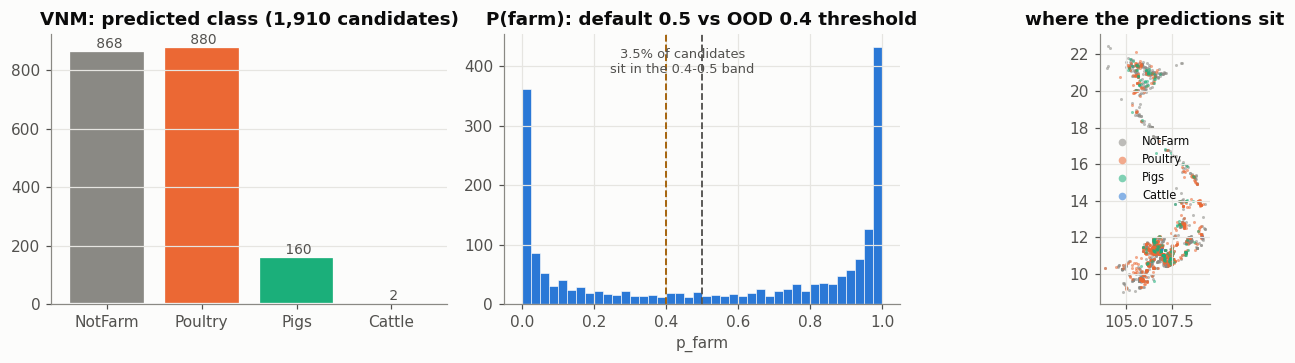

labels n=101 - model vs label:


model,NotFarm,Poultry
label,,
NotFarm,85,7
Poultry,0,9


candidate_id,stratum,model_pred,p_farm,label,verdict,note,find it
VNM_cluster_33,poultry_top,Poultry,1.00,None,right,Eight-barn complex on cleared ground in Red River paddies,map · sat
VNM_cluster_4021,poultry_top,Poultry,1.00,None,right,Two barn groups (5+3) carved into orchard land,map · sat
VNM_cluster_4311,poultry_top,Poultry,1.00,None,right,"Two fenced integrator compounds, CP-style",map · sat
VNM_cluster_499,poultry_top,Poultry,1.00,None,right,Twin dense blocks of ~8+6 barns with red support buildings,map · sat
VNM_cluster_5948,poultry_top,Poultry,1.00,None,right,15+ barns; dark pond suggests pigs possible,map · sat
VNM_cluster_6827,poultry_top,Poultry,1.00,None,right,Three joined wide barns in young plantation,map · sat
VNM_cluster_4332,pigs_top,Pigs,1.00,None,right,Dozens of barns + two REDDISH anaerobic lagoons - textbook swine,map · sat
VNM_cluster_5843,pigs_top,Pigs,1.00,None,right,Barn block ringed by dark treatment/fish ponds (VAC pattern),map · sat
VNM_cluster_6825,pigs_top,Pigs,0.99,None,right,"Ten barns, three dark lagoons alongside",map · sat
VNM_cluster_291,notfarm_top,NotFarm,0.01,None,right,Coastal theme park + rowhouse development,map · sat


In [3]:
iso = "VNM"
d = df[df.ADM0 == iso]
lab = d[d.true_label >= 0]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))

# 1. prediction composition (bar, class-colored)
counts = d.pred.value_counts().reindex(CLASSES).fillna(0)
axes[0].bar(counts.index, counts.values, color=[CLASS_COLOR[c] for c in counts.index],
            edgecolor="#fcfcfb", linewidth=1.5)
axes[0].set_title(f"{iso}: predicted class ({len(d):,} candidates)")
axes[0].grid(axis="x", visible=False)
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f" {int(v):,}", ha="center", va="bottom", fontsize=9, color=INK2)

# 2. p_farm distribution with decision thresholds
axes[1].hist(d.p_farm, bins=40, color="#2a78d6", edgecolor="#fcfcfb", linewidth=.4)
axes[1].axvline(0.5, color=INK2, lw=1.2, ls="--")
axes[1].axvline(0.4, color=WARN, lw=1.2, ls="--")
axes[1].set_title("P(farm): default 0.5 vs OOD 0.4 threshold")
axes[1].set_xlabel("p_farm")
axes[1].annotate(f"{(d.p_farm.between(.4,.5)).mean()*100:.1f}% of candidates\nsit in the 0.4-0.5 band",
                 xy=(.45,.95), xycoords="axes fraction", ha="center", va="top", fontsize=8.5, color=INK2)

# 3. spatial scatter
for cls in CLASSES:
    s = d[d.pred == cls]
    if len(s):
        axes[2].scatter(s.lng, s.lat, s=4, color=CLASS_COLOR[cls], alpha=.55, label=cls, linewidths=0)
axes[2].set_title("where the predictions sit")
axes[2].set_aspect("equal")
axes[2].legend(frameon=False, fontsize=7.5, markerscale=2.5, loc="best")
plt.tight_layout(); plt.show()

# labeled rows: model vs label
if len(lab):
    cm = pd.crosstab(lab.true_label.map(dict(enumerate(CLASSES))).rename("label"),
                     lab.pred.rename("model"))
    print(f"labels n={len(lab)} - model vs label:")
    display(cm)

# examples from the review, with map links
ex = V[V.iso == iso].merge(df[["candidate_id","lat","lng"]], on="candidate_id")
display(link_table(ex[["candidate_id","stratum","model_pred","p_farm","label","verdict","note"]]
        .to_dict("records")))

## Indonesia — two generations of kandang

2,442 candidates, 64% predicted farm. Java's poultry landscape shows both
housing generations side by side: cheap open-house *kandang terbuka*
(wood/bamboo, dark rusty roofs) and modern closed-house conversions (bright
metal, fan-ventilated) — the latter look exactly like training-set farms and
are easy; the former are the low-contrast hard cases at 10 m.

Regional priors matter more here than anywhere:

- **Pigs are confined** to North Sumatra, Bali, NTT, Batam — treat Java "Pigs"
  predictions with skepticism (the Batam top-pig pick shows *no structure at
  all* in current imagery).
- **Lampung/East Java cattle feedlots surface as Pigs** (IDN_5125): the model
  has no functional Cattle class, so feedlots get reassigned. Farm-level call
  stays right; the type is systematically wrong.
- FP families: schools/barracks rows, lake-cage aquaculture.

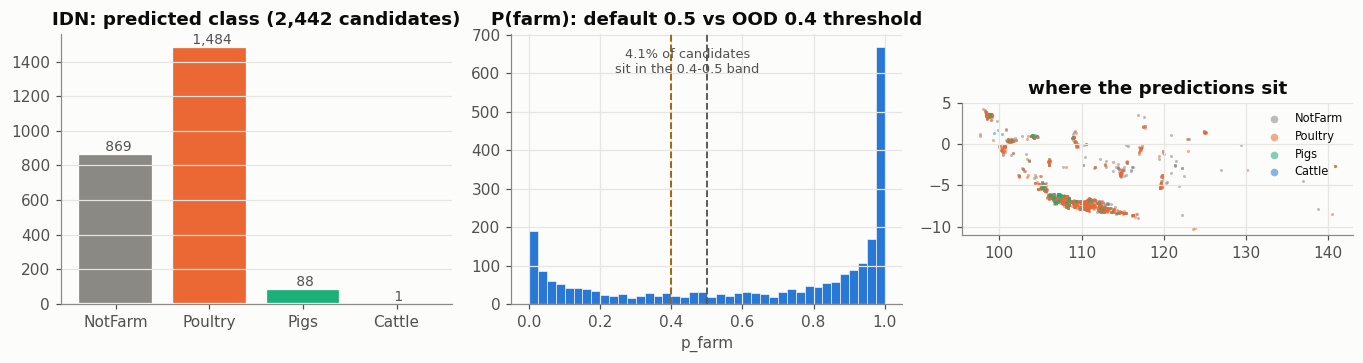

labels n=41 - model vs label:


model,NotFarm,Pigs,Poultry
label,,,
Cattle,0,1,0
NotFarm,25,0,1
Poultry,0,0,14


candidate_id,stratum,model_pred,p_farm,label,verdict,note,find it
IDN_cluster_2662,poultry_top,Poultry,1.00,None,right,Open kandang (dark roofs) + closed-house (white) side by side,map · sat
IDN_cluster_10062,poultry_top,Poultry,1.00,None,right,Shed strip along farm road in paddies,map · sat
IDN_cluster_2189,pigs_top,Pigs,0.98,None,no structure,Batam: nothing visible at location - mislocation or stale imagery,map · sat
IDN_cluster_5125,disagreement,Pigs,0.83,Cattle,right,"Lampung feedlot: farm yes, but Cattle -> Pigs (unlearnable class)",map · sat
IDN_cluster_7103,disagreement,Poultry,0.57,NotFarm,label right,"School/barracks compound, East Java; model hedged at 0.57",map · sat
IDN_cluster_1988,notfarm_top,NotFarm,0.00,None,right,"Lake aquaculture cage rafts, correctly refused",map · sat
IDN_cluster_494,borderline,NotFarm,0.50,None,ambiguous,Pesantren/school + greenhouse rows; probably NotFarm,map · sat


In [4]:
iso = "IDN"
d = df[df.ADM0 == iso]
lab = d[d.true_label >= 0]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))

# 1. prediction composition (bar, class-colored)
counts = d.pred.value_counts().reindex(CLASSES).fillna(0)
axes[0].bar(counts.index, counts.values, color=[CLASS_COLOR[c] for c in counts.index],
            edgecolor="#fcfcfb", linewidth=1.5)
axes[0].set_title(f"{iso}: predicted class ({len(d):,} candidates)")
axes[0].grid(axis="x", visible=False)
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f" {int(v):,}", ha="center", va="bottom", fontsize=9, color=INK2)

# 2. p_farm distribution with decision thresholds
axes[1].hist(d.p_farm, bins=40, color="#2a78d6", edgecolor="#fcfcfb", linewidth=.4)
axes[1].axvline(0.5, color=INK2, lw=1.2, ls="--")
axes[1].axvline(0.4, color=WARN, lw=1.2, ls="--")
axes[1].set_title("P(farm): default 0.5 vs OOD 0.4 threshold")
axes[1].set_xlabel("p_farm")
axes[1].annotate(f"{(d.p_farm.between(.4,.5)).mean()*100:.1f}% of candidates\nsit in the 0.4-0.5 band",
                 xy=(.45,.95), xycoords="axes fraction", ha="center", va="top", fontsize=8.5, color=INK2)

# 3. spatial scatter
for cls in CLASSES:
    s = d[d.pred == cls]
    if len(s):
        axes[2].scatter(s.lng, s.lat, s=4, color=CLASS_COLOR[cls], alpha=.55, label=cls, linewidths=0)
axes[2].set_title("where the predictions sit")
axes[2].set_aspect("equal")
axes[2].legend(frameon=False, fontsize=7.5, markerscale=2.5, loc="best")
plt.tight_layout(); plt.show()

# labeled rows: model vs label
if len(lab):
    cm = pd.crosstab(lab.true_label.map(dict(enumerate(CLASSES))).rename("label"),
                     lab.pred.rename("model"))
    print(f"labels n={len(lab)} - model vs label:")
    display(cm)

# examples from the review, with map links
ex = V[V.iso == iso].merge(df[["candidate_id","lat","lng"]], on="candidate_id")
display(link_table(ex[["candidate_id","stratum","model_pred","p_farm","label","verdict","note"]]
        .to_dict("records")))

## Philippines — the misses are the story

2,344 candidates and the highest farm rate (77%) — not contradicted by
sampling, consistent with integrator-driven density (San Miguel/Magnolia,
Bounty Fresh contract growing; tunnel-ventilated mega-farms in Mindanao).

The distinctive problem is **false negatives**: 6 of 10 label disagreements
are real farms the model rejects, all vegetation-embedded — barns in coconut
grove, jungle clearings, cluttered village mosaics. PHL_4056 is the emblem:
two obvious broiler houses, **in the training set**, scored p_farm 0.007.
No threshold rescues that; hypotheses are context mismatch with open-farmland
training imagery plus cloud-degraded S2 composites (PHL was a major
cloud-recovery country). The FP archetype is schools.

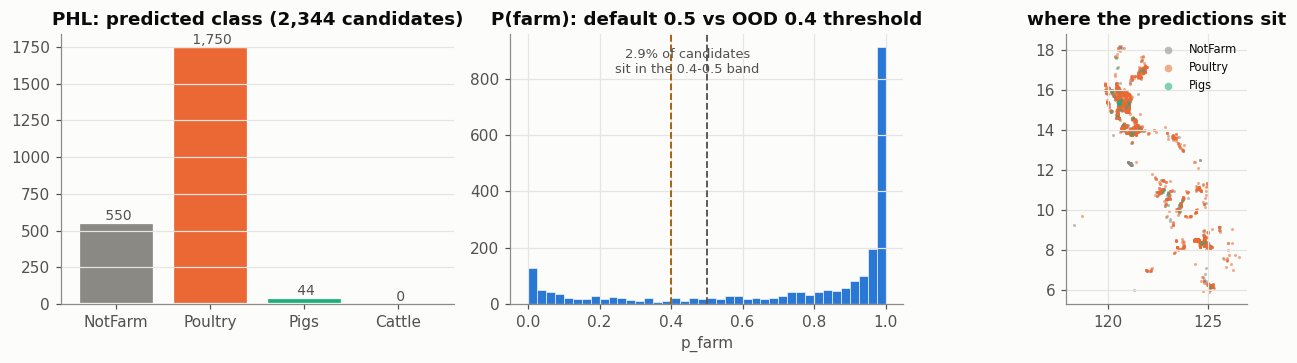

labels n=59 - model vs label:


model,NotFarm,Pigs,Poultry
label,,,
NotFarm,17,0,4
Pigs,0,1,0
Poultry,6,0,31


candidate_id,stratum,model_pred,p_farm,label,verdict,note,find it
PHL_cluster_1053,poultry_top,Poultry,1.000,None,right,Rusty open-sided houses among smallholdings + fish ponds,map · sat
PHL_cluster_285,pigs_top,Pigs,0.990,None,right,"Five-barn block at wood edge; no lagoon visible, type uncertain",map · sat
PHL_cluster_4056,disagreement,NotFarm,0.007,Poultry,model wrong,"TRAIN ROW: two obvious broiler houses in jungle clearing, missed at 0.007",map · sat
PHL_cluster_3929,disagreement,NotFarm,0.280,Poultry,model wrong,3-4 metal barns tucked in peri-urban village mosaic,map · sat
PHL_cluster_1022,disagreement,Poultry,0.790,NotFarm,model wrong,School campus: long classroom blocks = barn mimics,map · sat


In [5]:
iso = "PHL"
d = df[df.ADM0 == iso]
lab = d[d.true_label >= 0]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))

# 1. prediction composition (bar, class-colored)
counts = d.pred.value_counts().reindex(CLASSES).fillna(0)
axes[0].bar(counts.index, counts.values, color=[CLASS_COLOR[c] for c in counts.index],
            edgecolor="#fcfcfb", linewidth=1.5)
axes[0].set_title(f"{iso}: predicted class ({len(d):,} candidates)")
axes[0].grid(axis="x", visible=False)
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f" {int(v):,}", ha="center", va="bottom", fontsize=9, color=INK2)

# 2. p_farm distribution with decision thresholds
axes[1].hist(d.p_farm, bins=40, color="#2a78d6", edgecolor="#fcfcfb", linewidth=.4)
axes[1].axvline(0.5, color=INK2, lw=1.2, ls="--")
axes[1].axvline(0.4, color=WARN, lw=1.2, ls="--")
axes[1].set_title("P(farm): default 0.5 vs OOD 0.4 threshold")
axes[1].set_xlabel("p_farm")
axes[1].annotate(f"{(d.p_farm.between(.4,.5)).mean()*100:.1f}% of candidates\nsit in the 0.4-0.5 band",
                 xy=(.45,.95), xycoords="axes fraction", ha="center", va="top", fontsize=8.5, color=INK2)

# 3. spatial scatter
for cls in CLASSES:
    s = d[d.pred == cls]
    if len(s):
        axes[2].scatter(s.lng, s.lat, s=4, color=CLASS_COLOR[cls], alpha=.55, label=cls, linewidths=0)
axes[2].set_title("where the predictions sit")
axes[2].set_aspect("equal")
axes[2].legend(frameon=False, fontsize=7.5, markerscale=2.5, loc="best")
plt.tight_layout(); plt.show()

# labeled rows: model vs label
if len(lab):
    cm = pd.crosstab(lab.true_label.map(dict(enumerate(CLASSES))).rename("label"),
                     lab.pred.rename("model"))
    print(f"labels n={len(lab)} - model vs label:")
    display(cm)

# examples from the review, with map links
ex = V[V.iso == iso].merge(df[["candidate_id","lat","lng"]], on="candidate_id")
display(link_table(ex[["candidate_id","stratum","model_pred","p_farm","label","verdict","note"]]
        .to_dict("records")))

## The Đồng Nai hotspot: what one 2.7 km box contains

Around the top pig prediction (`VNM_cluster_4332`), a 3×3 grid of zoom-16
tiles shows the density — and the gaps — of candidate coverage.

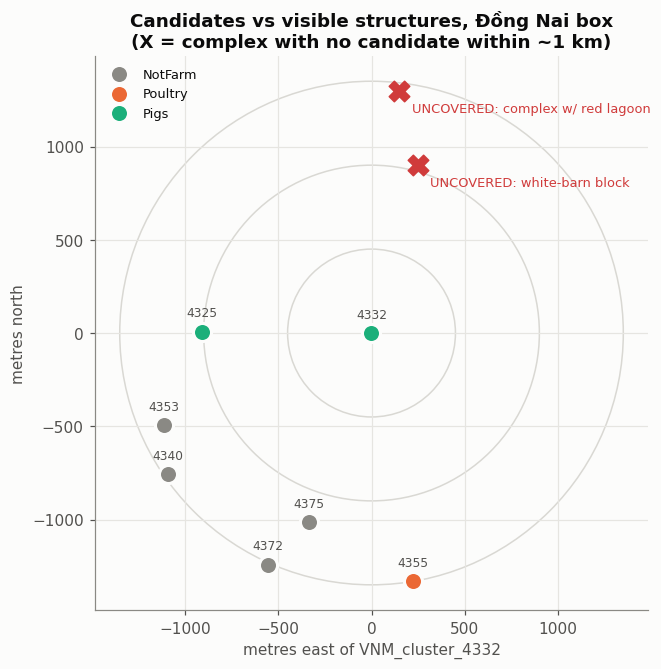

candidate_id,pred,p_farm,find it
VNM_cluster_4355,Poultry,1.00,map · sat
VNM_cluster_4332,Pigs,1.00,map · sat
VNM_cluster_4325,Pigs,0.99,map · sat
VNM_cluster_4375,NotFarm,0.37,map · sat
VNM_cluster_4372,NotFarm,0.13,map · sat
VNM_cluster_4340,NotFarm,0.11,map · sat
VNM_cluster_4353,NotFarm,0.04,map · sat


In [6]:
lat0, lng0 = 11.33222, 107.13740
d = df[df.ADM0 == "VNM"]
box = d[(d.lat.between(lat0-0.0125, lat0+0.0125)) & (d.lng.between(lng0-0.0125, lng0+0.0125))].copy()
box["dE"] = (box.lng-lng0)*111320*np.cos(np.radians(lat0))
box["dN"] = (box.lat-lat0)*111320

fig, ax = plt.subplots(figsize=(6.2, 6.2))
for cls in CLASSES:
    s = box[box.pred == cls]
    if len(s):
        ax.scatter(s.dE, s.dN, s=140, color=CLASS_COLOR[cls], label=cls,
                   edgecolor="#fcfcfb", linewidth=2, zorder=3)
for _, r in box.iterrows():
    ax.annotate(r.candidate_id.replace("VNM_cluster_",""), (r.dE, r.dN),
                xytext=(0,10), textcoords="offset points", ha="center", fontsize=8, color=INK2)
# the two structures found in imagery with NO candidate
for (dE,dN,name) in [(250,900,"white-barn block"),(150,1300,"complex w/ red lagoon")]:
    ax.scatter([dE],[dN], s=180, marker="X", color=BAD, zorder=4)
    ax.annotate(f"UNCOVERED: {name}", (dE,dN), xytext=(8,-14), textcoords="offset points",
                fontsize=8.5, color=BAD)
for r in (450, 900, 1350):
    ax.add_patch(plt.Circle((0,0), r, fill=False, color="#d9d8d3", lw=1))
ax.set_xlabel("metres east of VNM_cluster_4332"); ax.set_ylabel("metres north")
ax.set_title("Candidates vs visible structures, Đồng Nai box\n(X = complex with no candidate within ~1 km)")
ax.legend(frameon=False, fontsize=8.5)
ax.set_aspect("equal")
plt.tight_layout(); plt.show()

display(link_table(box.sort_values("p_farm", ascending=False)
        [["candidate_id","pred","p_farm"]].round(2).to_dict("records")))

## Synthesis

| | Vietnam | Indonesia | Philippines |
|---|---|---|---|
| Top predictions | excellent | excellent | good |
| FP family | shade-net horticulture | schools, aquaculture | schools |
| FN family | (none sampled) | open kandang (low contrast) | vegetation-embedded barns |
| Type calls | pigs credible (lagoons) | feedlots→"Pigs" | mostly untestable |
| Distinctive risk | high-rise pig farms | regional pig priors | cloud + jungle context |

**Actions this feeds:** the candidate-recall audit (E2.7 — now with direct
evidence), hard-negative labeling of the four FP families, cloud-handling work
(E1.3) for the Philippine FN cluster, the Cattle merge, and blind re-annotation
of Vietnamese "NotFarm" labels on barn-like rows (E0.4).